<a href="https://colab.research.google.com/github/antonellagambarte/deep-learning--CEIA/blob/main/Copia_de_GAMBARTE_ANTONELLA_NEREA_DL_TP1_Co21_intermedio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Resolución trabajo práctico N°1 - Aprendizaje Profundo**

1 a) Implementación del Gradiente Descendente

Bibliotecas necesarias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Generación de dataset sintético y funciones auxiliares

In [ ]:
np.random.seed(7)

#Generación de dataset sintético
inicio, fin, n = -3, 3, 200
x = np.linspace(inicio, fin, n)

# función no lineal + ruido
y = np.sin(2 * x) + 0.3 * np.random.randn(n)

def forward_pass(w,b,x):
  z= w * x + b # red de una sola neurona
  return np.tanh(z), z # paso resultado por función de activación

# Función de costo
def mse_loss(y_pred,y):
  return np.mean((y_pred - y)**2)

# Función para calcular los gradientes
# recibe el peso, bias, batch de entrada y salida
def gradientes(w, b, x_batch, y_batch):
    m = x_batch.shape[0] # número de filas
    y_hat, z = forward_pass(w, b, x_batch) # propagación hacia adelante
    err = y_hat - y_batch
    dz_dw = (1 - np.tanh(z) ** 2) * x_batch
    dz_db = (1 - np.tanh(z) ** 2)
    dw = (2.0 / m) * np.sum(err * dz_dw) #regla de la cadena
    db = (2.0 / m) * np.sum(err * dz_db) #regla de la cadena
    return dw, db



A continuación, se implementa el algoritmo de Gradiente Descendente

In [ ]:
# La función recibe el valor inicial de w, b, los datos de entrada x, los valores reales y, y la taza de aprendizaje
def gradiente_descendente(w0, b0, x, y, lr):
  epochs = 100 # cantidad de épocas según enunciado
  w, b = w0, b0
  history = {'w': [], 'b': [], 'loss': []}

  for epoch in range(epochs):
      dw, db = gradientes(w, b, x, y)
      w = w - lr * dw
      b = b - lr * db
      y_hat, _ = forward_pass(w, b, x)
      loss = mse_loss(y_hat, y)
      history['w'].append(w)
      history['b'].append(b)
      history['loss'].append(loss)
  return history


Uso del algoritmo para distintos learning rates

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
results = {}

# Inicialización ramdon de w y b para los distintos learning rates
for lr in learning_rates:
    w0 = np.random.randn()
    b0 = np.random.randn()
    results[lr] = {'init': (w0, b0)}

# Ejecutción Gradient Descent para los distintos learning rates
for lr in learning_rates:
    w0, b0 = results[lr]['init']
    hist_gd = gradiente_descendente(w0, b0, x, y, lr)
    results[lr]['gd'] = hist_gd

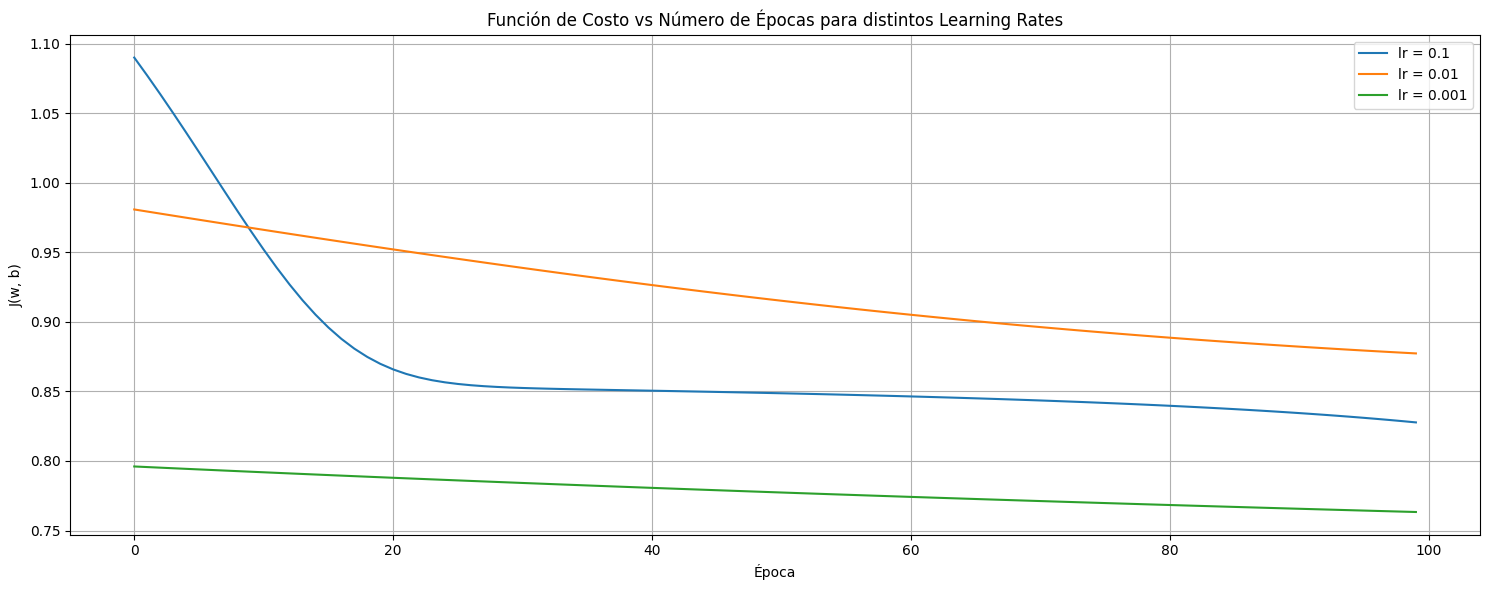

In [ ]:
plt.figure(figsize=(15, 6))

for lr in learning_rates:
    history = results[lr]['gd']
    plt.plot(history['loss'], label=f'lr = {lr}')

plt.xlabel('Época')
plt.ylabel('J(w, b)')
plt.title('Función de Costo vs Número de Épocas para distintos Learning Rates')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

1 b) Implemetación de Adam

In [ ]:
# para beta1, beta2 y eps se toma los valores recomendados en el paper "Adam: A Method for Stochastic Optimization"
# link: https://arxiv.org/pdf/1412.6980
def adam(w0, b0, x, y, lr, epochs=100, batch_size=None, beta1=0.9, beta2=0.999, eps=1e-8):
    np.random.seed(7)
  # inicialización de pesos y bias
    w, b = w0, b0
  # momentos de primer y segundo orden inicializados en cero
    mw, vw = 0.0, 0.0
    mb, vb = 0.0, 0.0
    history = {'w': [], 'b': [], 'loss': []}
    m = x.shape[0]
    step = 0

    # Si batch_size es None -> full-batch
    for t in range(1, epochs + 1):
        if batch_size is None:
            x_batch, y_batch = x, y
        else:
            # bloque mini-batch
            idx = np.random.choice(m, batch_size, replace=False) # seleccionar un mini-batch aleatorio sin repetición. Esto permite que los gradientes sean estocásticos,
                                                                 # como Adam asume, evitando sesgos por el orden de los datos y mejorando la convergencia.
                                                                 # (https://www.geeksforgeeks.org/machine-learning/difference-between-batch-gradient-descent-and-stochastic-gradient-descent)
            x_batch, y_batch = x[idx], y[idx]

        dw, db = gradientes(w, b, x_batch, y_batch)

        # Actualización de momentos
        mw = beta1 * mw + (1 - beta1) * dw
        mb = beta1 * mb + (1 - beta1) * db
        vw = beta2 * vw + (1 - beta2) * (dw ** 2)
        vb = beta2 * vb + (1 - beta2) * (db ** 2)

        # Corrección bias
        mw_hat = mw / (1 - beta1 ** t)
        mb_hat = mb / (1 - beta1 ** t)
        vw_hat = vw / (1 - beta2 ** t)
        vb_hat = vb / (1 - beta2 ** t)

        # Actualización de parámetros
        w = w - lr * mw_hat / (np.sqrt(vw_hat) + eps)
        b = b - lr * mb_hat / (np.sqrt(vb_hat) + eps)

        y_hat, _ = forward_pass(w, b, x)
        loss = mse_loss(y_hat, y)
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(loss)
    return history



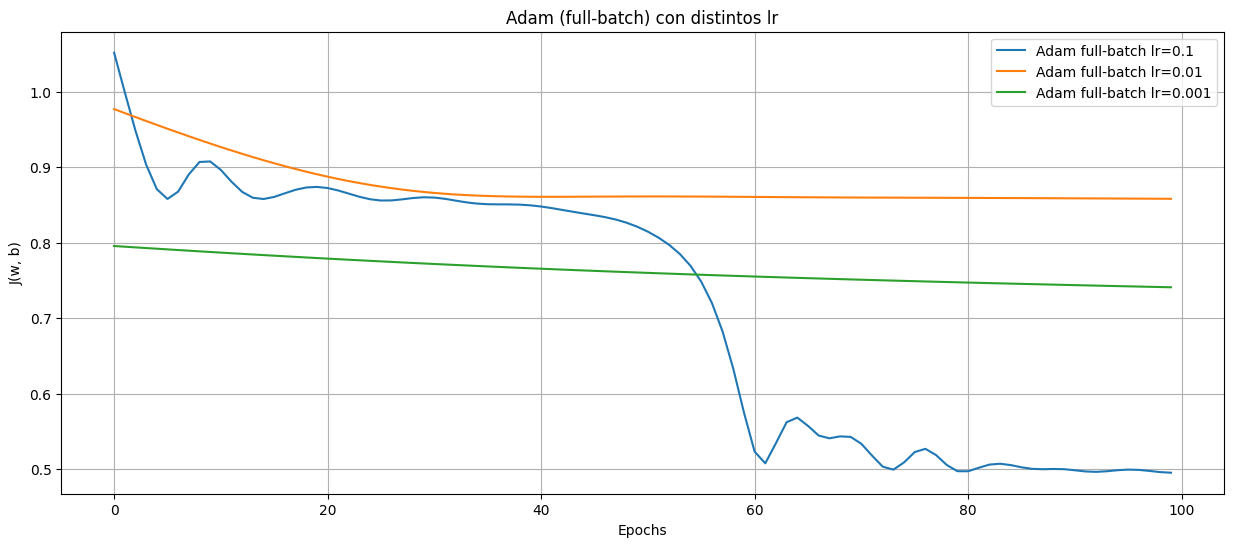

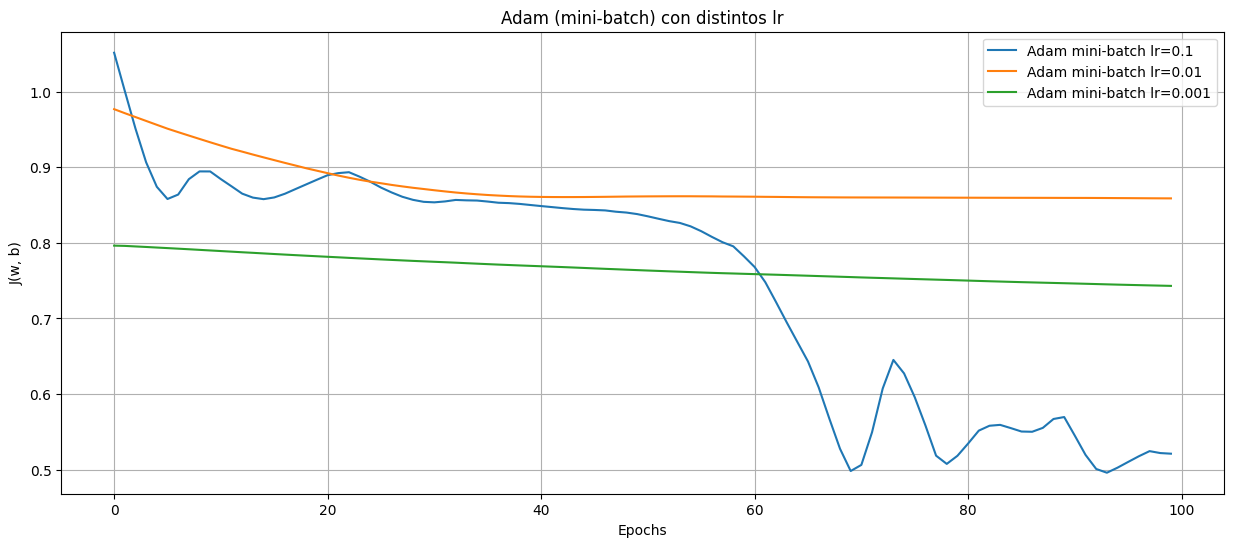

In [ ]:
epochs = 100
# Ejecutar Adam full-batch (usando mismos w0,b0 que GD por lr)
for lr in learning_rates:
    w0, b0 = results[lr]['init']
    hist_adam_full = adam(w0, b0, x, y, lr, epochs=epochs, batch_size=None)
    results[lr]['adam_full'] = hist_adam_full

# Ejecutar Adam mini-batch (batch size elegido = 20)
batch_size = 20
for lr in learning_rates:
    w0, b0 = results[lr]['init']
    hist_adam_mini = adam(w0, b0, x, y, lr, epochs=epochs, batch_size=batch_size)
    results[lr]['adam_mini'] = hist_adam_mini


# Adam full-batch
plt.figure(figsize=(15,6))
for lr in learning_rates:
    history_adam = results[lr]['adam_full']
    plt.plot(history_adam["loss"], label=f"Adam full-batch lr={lr}")
plt.xlabel("Epochs")
plt.ylabel("J(w, b)")
plt.title("Adam (full-batch) con distintos lr")
plt.grid(True)
plt.legend()
plt.show()

# Adam mini-batch
plt.figure(figsize=(15,6))
for lr in learning_rates:
    history_adam_mb = results[lr]['adam_mini']
    plt.plot(history_adam_mb["loss"], label=f"Adam mini-batch lr={lr}")
plt.xlabel("Epochs")
plt.ylabel("J(w, b)")
plt.title("Adam (mini-batch) con distintos lr")
plt.grid(True)
plt.legend()
plt.show()



1c)

Para learning rate = 0.1
- En el caso de Gradient Descent (GD), el loss baja al principio pero luego se aplana y converge lentamente.

- En el caso de Adam full batch, el loss comienza con oscilaciones pero mas o menos a partir de la época 55 comienza a bajar considerablemente. Si bien comienza con oscilaciones, consigue un loss mejor que GD.

- Para el caso de Adam mini batch, presenta oscilaciones similares al full-batch, pero alcanza el mínimo más rápidamente, y también logra el menor valor de loss entre todos los métodos para este learning rate.

Para learning rate = 0.01
- Para GD, el loss disminuye de forma más lenta pero prograsiva pero con peor resultado que con lr = 0.1.
- Para Adam full bach, el loss desciende suavemente pero con peor resultado que lr = 0.1.
- En el caso de Adam mini batch, tiene el mismo comportamiento que full batch, sin mejoras.

Para learning rate = 0.001
- GD: se obtienen mejores resultado que con los anteriores lr, pero no mejor que adam. El loss sigue siendo alto.
- Adam full batch: es la más lenta, pero baja de forma estable y consistente.
- Adam mini batch: tambien baja despacio, estable, pero no obtiene mejores resultados que con Adam con lr = 0.1 dentro de las 100 épocas.

### **Conclusiones**
- GD: depende mucho del lr, converge más lento y no alcanza mínimos tan bajos.
- Adam full-batch: mejora frente a GD, pero con lr=0.1 recién muestra buenos resultados después de muchas épocas.
- Adam mini-batch: es el más eficiente. Con lr=0.1 llega al mejor costo rápido. Con lr más bajos es más lento.

1d) Visualización en 3D de la trayectoria de aprendizaje

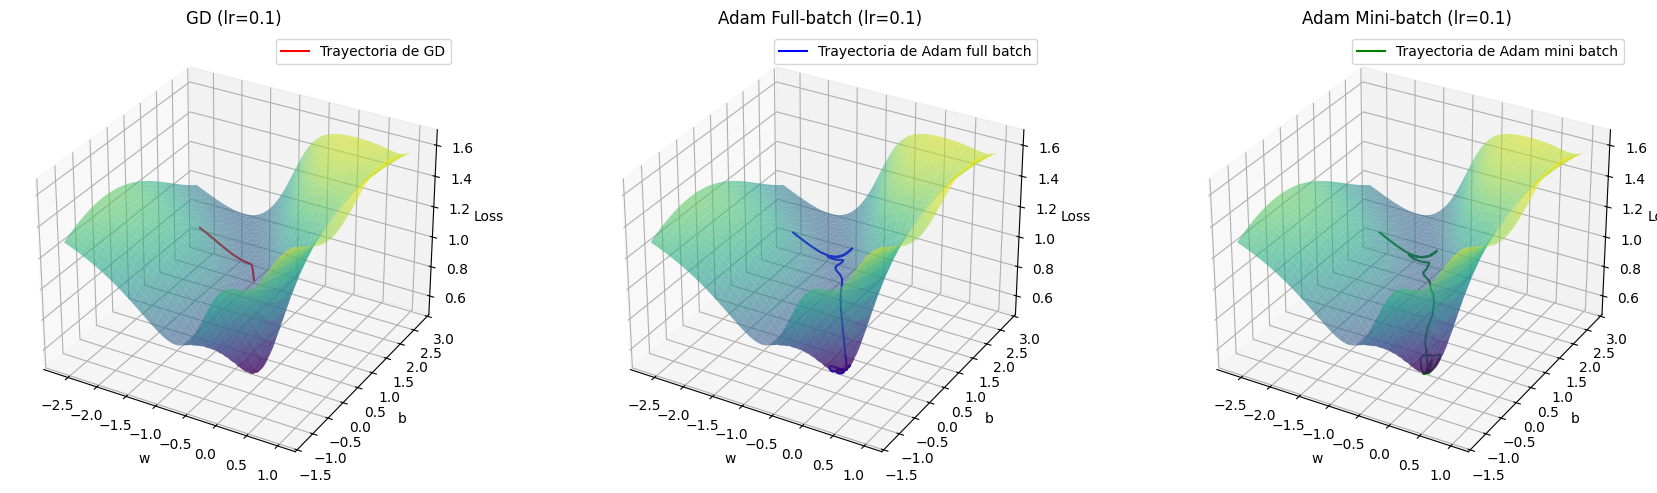

In [ ]:
chosen_lr = 0.1
traj_gd = results[chosen_lr]['gd']
traj_adam_full = results[chosen_lr]['adam_full']
traj_adam_mini = results[chosen_lr]['adam_mini']

w_vals = np.linspace(min(min(traj_gd['w']), min(traj_adam_full['w']), min(traj_adam_mini['w'])) - 1,
                     max(max(traj_gd['w']), max(traj_adam_full['w']), max(traj_adam_mini['w'])) + 1, 80)
b_vals = np.linspace(min(min(traj_gd['b']), min(traj_adam_full['b']), min(traj_adam_mini['b'])) - 1,
                     max(max(traj_gd['b']), max(traj_adam_full['b']), max(traj_adam_mini['b'])) + 1, 80)
W, B = np.meshgrid(w_vals, b_vals)
Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        yhat, _ = forward_pass(W[i,j], B[i,j], x)
        Z[i,j] = mse_loss(yhat, y)

fig = plt.figure(figsize=(18,5))

# GD
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(W, B, Z, cmap="viridis", alpha=0.6)
ax1.plot(traj_gd['w'], traj_gd['b'], traj_gd['loss'], color="red", label="Trayectoria de GD")
ax1.set_title("GD (lr=0.1)")
ax1.set_xlabel("w")
ax1.set_ylabel("b")
ax1.set_zlabel("Loss")
ax1.legend()

# Adam Full-batch
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(W, B, Z, cmap="viridis", alpha=0.6)
ax2.plot(traj_adam_full['w'], traj_adam_full['b'], traj_adam_full['loss'], color="blue", label="Trayectoria de Adam full batch")
ax2.set_title("Adam Full-batch (lr=0.1)")
ax2.set_xlabel("w")
ax2.set_ylabel("b")
ax2.set_zlabel("Loss")
ax2.legend()

# Adam Mini-batch
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(W, B, Z, cmap="viridis", alpha=0.6)
ax3.plot(traj_adam_mini['w'], traj_adam_mini['b'], traj_adam_mini['loss'], color="green", label="Trayectoria de Adam mini batch")
ax3.set_title("Adam Mini-batch (lr=0.1)")
ax3.set_xlabel("w")
ax3.set_ylabel("b")
ax3.set_zlabel("Loss")
ax3.legend()

plt.tight_layout()
plt.show()
